**Ramyapriya Sivasankar** - **RA2411026010734**

Submission for IEEE RnD task

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
print("Loading MNIST dataset...")

mnist = fetch_openml('mnist_784', version=1)
X = mnist.data
y = mnist.target.astype(int)

print("Dataset shape:", X.shape)

Loading MNIST dataset...
Dataset shape: (70000, 784)


In [ ]:
# Normalize pixel values (0-255 → 0-1)
X = X / 255.0

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (56000, 784)
Testing samples: (14000, 784)


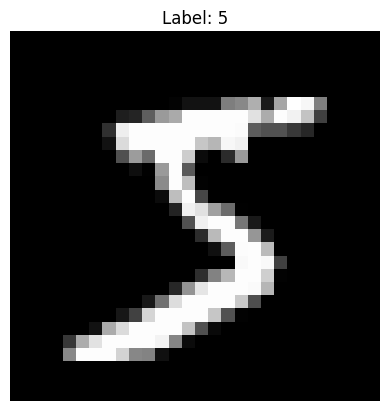

In [ ]:
plt.imshow(X.iloc[0].values.reshape(28,28), cmap='gray')
plt.title(f"Label: {y[0]}")
plt.axis('off')
plt.show()

In [ ]:
print("Training model...")

model = MLPClassifier(
    hidden_layer_sizes=(128,),
    max_iter=20,
    solver='adam',
    alpha=1e-4,
    random_state=42,
    verbose=True
)

model.fit(X_train, y_train)

print("Training Completed!")

Training model...
Iteration 1, loss = 0.42473059
Iteration 2, loss = 0.19824993
Iteration 3, loss = 0.14820670
Iteration 4, loss = 0.11724433
Iteration 5, loss = 0.09662182
Iteration 6, loss = 0.08035723
Iteration 7, loss = 0.06790252
Iteration 8, loss = 0.05895092
Iteration 9, loss = 0.05065377
Iteration 10, loss = 0.04440961
Iteration 11, loss = 0.03852181
Iteration 12, loss = 0.03425592
Iteration 13, loss = 0.02948661
Iteration 14, loss = 0.02613502
Iteration 15, loss = 0.02338415
Iteration 16, loss = 0.02032658
Iteration 17, loss = 0.01777321
Iteration 18, loss = 0.01552399
Iteration 19, loss = 0.01376388
Iteration 20, loss = 0.01233934
Training Completed!


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9757857142857143

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1343
           1       0.99      0.99      0.99      1600
           2       0.97      0.98      0.97      1380
           3       0.96      0.98      0.97      1433
           4       0.97      0.97      0.97      1295
           5       0.99      0.97      0.98      1273
           6       0.98      0.99      0.99      1396
           7       0.97      0.98      0.98      1503
           8       0.97      0.95      0.96      1357
           9       0.96      0.96      0.96      1420

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



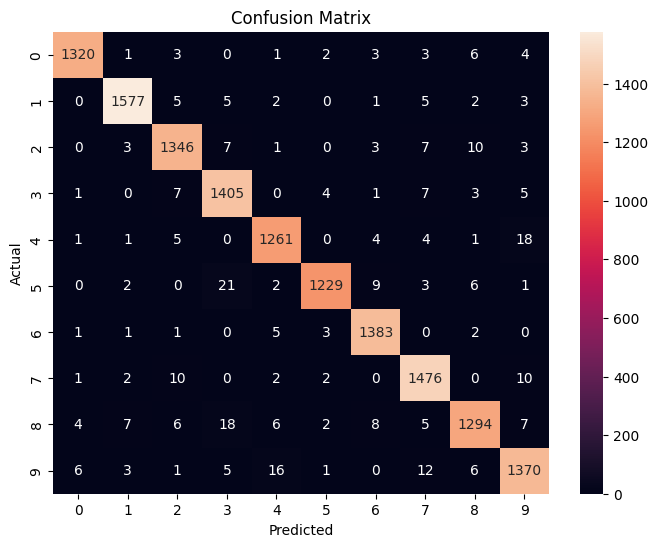

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


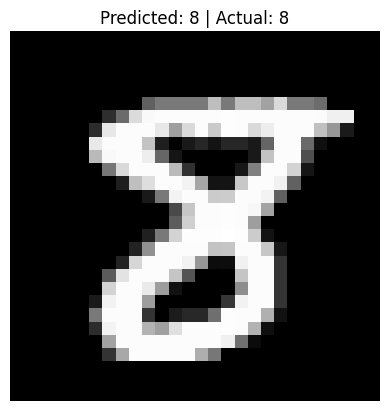

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


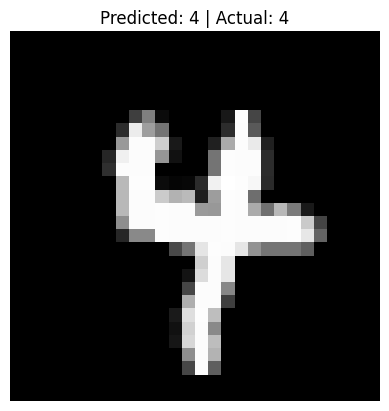

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


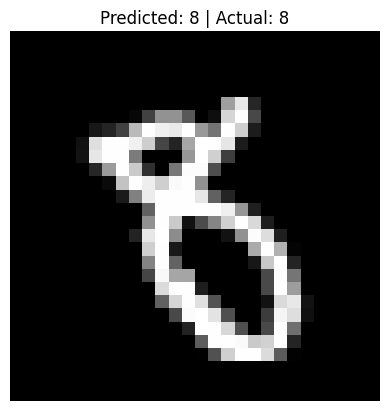

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


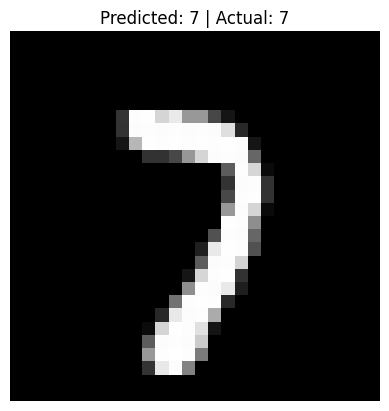

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


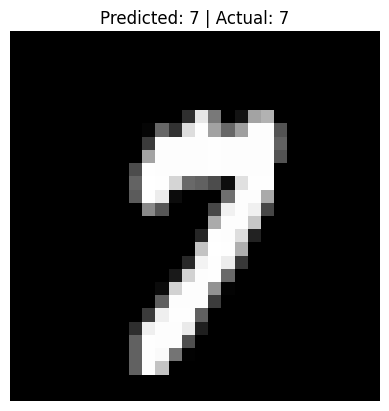

In [ ]:
for i in range(5):
    sample = X_test.iloc[i].values.reshape(1, -1)
    prediction = model.predict(sample)

    plt.imshow(X_test.iloc[i].values.reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {prediction[0]} | Actual: {y_test.iloc[i]}")
    plt.axis('off')
    plt.show()

In [ ]:
probabilities = model.predict_proba(sample)
print("Confidence Scores:", probabilities)

Confidence Scores: [[3.19502715e-10 1.70705637e-08 8.37739918e-09 2.05830657e-09
  1.90402149e-09 8.59540803e-11 3.48861262e-16 9.99961775e-01
  3.39912069e-08 3.81608995e-05]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


Total misclassified samples: 339


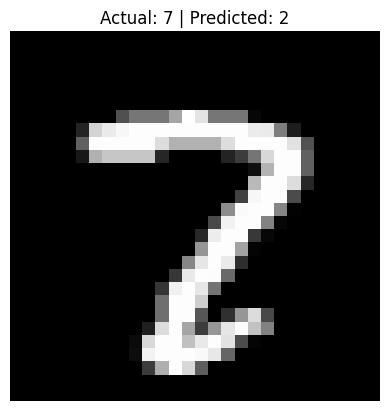

In [ ]:
misclassified = np.where(y_test != y_pred)[0]

print("Total misclassified samples:", len(misclassified))

index = misclassified[0]

plt.imshow(X_test.iloc[index].values.reshape(28,28), cmap='gray')
plt.title(f"Actual: {y_test.iloc[index]} | Predicted: {y_pred[index]}")
plt.axis('off')
plt.show()

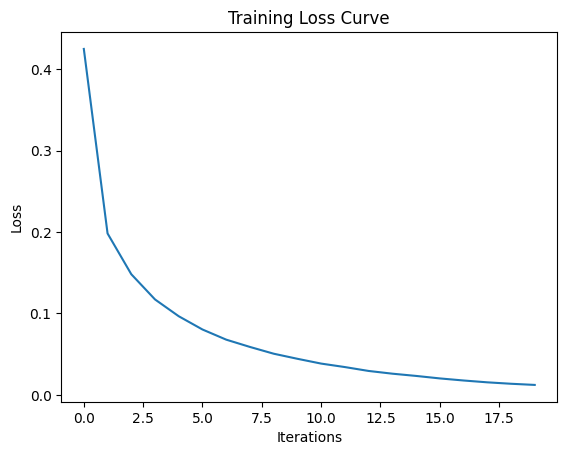

In [11]:
plt.plot(model.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

<Axes: >

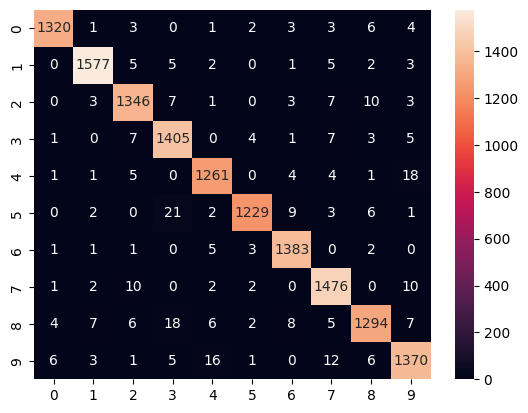

In [12]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')

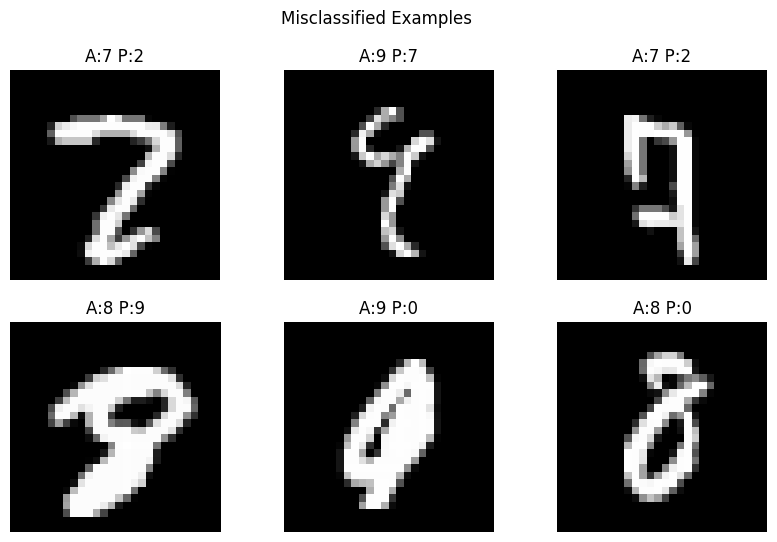

In [13]:
misclassified = np.where(y_test != y_pred)[0]

plt.figure(figsize=(10,6))

for i in range(6):
    index = misclassified[i]

    plt.subplot(2,3,i+1)
    plt.imshow(X_test.iloc[index].values.reshape(28,28), cmap='gray')
    plt.title(f"A:{y_test.iloc[index]} P:{y_pred[index]}")
    plt.axis('off')

plt.suptitle("Misclassified Examples")
plt.show()